# Лабораторная работа 14 Клименчук Илья ИПО-2-2022

Тема: **Подбор гиперпараметров и ранняя остановка (PyTorch + Optuna) на MNIST**  
Формат: практическая работа с обязательными собственными экспериментами и текстовыми выводами.

> Этот ноутбук оформлен как задание, а не готовый отчёт.  
> Код даёт каркас, но **основные баллы** ставятся за ваши собственные настройки, графики и объяснения.  
> Текстовые ответы должны быть согласованы с вашими конкретными числами и графиками, а не выглядеть как универсальные формулировки из интернета.


## 1. Ваше понимание гиперпараметров и ранней остановки

До запуска кода сформулируйте (8–12 предложений):

1. Какие величины в нейросетях вы называете **гиперпараметрами**, а какие — **обучаемыми параметрами**.  
2. Зачем вообще подбирать гиперпараметры (learning rate, размер скрытого слоя, dropout) и почему «на глаз» это делать сложно.  
3. Что вы ожидаете от механизма **ранней остановки**: в каких ситуациях он помогает, а когда может мешать добраться до лучшего качества.

Пишите своими словами, не пытаясь угадать «идеальное» определение.


In [2]:
intro_text = """
Гиперпараметрами в нейросети мы называем такие величины, которые задаются до начала обучения и не подбираются градиентным спуском автоматически. 
К ним относятся, например, learning rate, размер скрытого слоя, число слоёв, dropout, batch size и число эпох. Обучаемые параметры — это уже сами веса и смещения слоёв, которые меняются во время обучения на основе функции потерь.
Подбор гиперпараметров важен потому, что от них напрямую зависит, насколько быстро модель сходится, насколько хорошо обобщает данные и не переобучается ли она. 
Один и тот же MLP при слишком большом learning rate может обучаться нестабильно, а при слишком маленьком — сходиться очень медленно. 
Размер скрытого слоя влияет на ёмкость модели: слишком маленький слой может не уловить структуру данных, а слишком большой увеличивает риск переобучения.
Dropout тоже нужно подбирать аккуратно, потому что слабый dropout может не давать достаточной регуляризации, а слишком сильный ухудшает обучение даже на простых данных. 
Делать такой подбор «на глаз» трудно, потому что гиперпараметры влияют друг на друга и их эффект зависит от конкретной задачи.
Ранняя остановка нужна для того, чтобы вовремя прекратить обучение, если качество на валидации перестало улучшаться. Она помогает экономить время и часто уменьшает переобучение, но в некоторых случаях может остановить обучение слишком рано, если метрика временно колеблется и модель ещё могла бы улучшиться.
"""
print(intro_text)


Гиперпараметрами в нейросети мы называем такие величины, которые задаются до начала обучения и не подбираются градиентным спуском автоматически. 
К ним относятся, например, learning rate, размер скрытого слоя, число слоёв, dropout, batch size и число эпох. Обучаемые параметры — это уже сами веса и смещения слоёв, которые меняются во время обучения на основе функции потерь.
Подбор гиперпараметров важен потому, что от них напрямую зависит, насколько быстро модель сходится, насколько хорошо обобщает данные и не переобучается ли она. 
Один и тот же MLP при слишком большом learning rate может обучаться нестабильно, а при слишком маленьком — сходиться очень медленно. 
Размер скрытого слоя влияет на ёмкость модели: слишком маленький слой может не уловить структуру данных, а слишком большой увеличивает риск переобучения.
Dropout тоже нужно подбирать аккуратно, потому что слабый dropout может не давать достаточной регуляризации, а слишком сильный ухудшает обучение даже на простых данных. 
Дела

## 2. Импорт, настройки и данные (MNIST)


In [4]:
import warnings
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, TensorDataset

# Небольшой защитный патч: в некоторых окружениях torchvision падает
# на этапе импорта из-за регистрации torchvision::nms.
TV_AVAILABLE = True
torchvision_import_error = None

try:
    original_register_fake = torch.library.register_fake

    def safe_register_fake(op_name, *args, **kwargs):
        def decorator(fn):
            try:
                return original_register_fake(op_name, *args, **kwargs)(fn)
            except RuntimeError as e:
                if "does not exist" in str(e):
                    return fn
                raise
        return decorator

    torch.library.register_fake = safe_register_fake
    from torchvision import datasets, transforms
except Exception as e:
    TV_AVAILABLE = False
    torchvision_import_error = e
    datasets = None
    transforms = None
    warnings.warn(f"torchvision импортировать не удалось: {e}")

import optuna
from optuna.pruners import MedianPruner

import matplotlib.pyplot as plt
import pandas as pd

MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

batch_size = 128

if TV_AVAILABLE:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    try:
        full_train = datasets.MNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform,
        )

        val_size = 10000
        train_size = len(full_train) - val_size
        split_generator = torch.Generator().manual_seed(MY_SEED)
        train_dataset, val_dataset = random_split(
            full_train,
            [train_size, val_size],
            generator=split_generator
        )

        test_dataset = datasets.MNIST(
            root="./data",
            train=False,
            download=True,
            transform=transform,
        )
        dataset_name = "MNIST"
    except Exception as e:
        print("Не удалось загрузить MNIST, используем sklearn digits как fallback.")
        print("Причина:", e)
        TV_AVAILABLE = False

if not TV_AVAILABLE:
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split

    digits = load_digits()
    X = digits.images.astype(np.float32) / 16.0
    y = digits.target.astype(np.int64)

    # Приведём 8x8 к 28x28 через pad, чтобы не ломать MLP по размеру входа.
    X_pad = np.pad(X, ((0, 0), (10, 10), (10, 10)), mode="constant")
    mean = 0.1307
    std = 0.3081
    X_pad = (X_pad - mean) / std
    X_pad = X_pad[:, None, :, :]  # N, 1, 28, 28

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_pad, y, test_size=0.2, random_state=MY_SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=MY_SEED, stratify=y_temp
    )

    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )
    full_train = TensorDataset(
        torch.tensor(np.concatenate([X_train, X_val], axis=0), dtype=torch.float32),
        torch.tensor(np.concatenate([y_train, y_val], axis=0), dtype=torch.long)
    )
    dataset_name = "sklearn digits fallback"

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Источник данных:", dataset_name)
print("Размер train:", len(train_dataset))
print("Размер val  :", len(val_dataset))
print("Размер test :", len(test_dataset))
print("batch_size  :", batch_size)

Устройство: cpu
MY_SEED = 42
Источник данных: MNIST
Размер train: 50000
Размер val  : 10000
Размер test : 10000
batch_size  : 128


## 3. Базовый MLP и класс ранней остановки

Модель: вход 28×28 → скрытый слой → dropout → выход на 10 логитов.


In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, hidden_dim=256, dropout_p=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

print("Класс EarlyStopping определён.")

Класс EarlyStopping определён.


### Мини‑обсуждение ранней остановки

Опишите в 4–6 предложениях:
- как именно по этому коду принимается решение «останавливать/не останавливать»;  
- почему хранится копия **лучшего** состояния модели, а не только номер эпохи.


In [7]:
es_comment = """
В этом коде ранняя остановка отслеживает значение val_loss после каждой эпохи.
Если текущий val_loss оказывается лучше предыдущего лучшего значения хотя бы на min_delta, то счётчик неудачных эпох сбрасывается в ноль, а состояние модели сохраняется как лучшее. 
Если улучшения нет, счётчик увеличивается. 
Когда число таких эпох подряд достигает patience, обучение останавливается. 
Хранить копию лучшего состояния модели важно потому, что последняя эпоха перед остановкой не обязательно является лучшей: качество на валидации могло начать ухудшаться ещё раньше. 
Поэтому после остановки мы возвращаем именно тот набор весов, на котором val_loss был минимальным, а не просто используем финальное состояние.
"""
print(es_comment)


В этом коде ранняя остановка отслеживает значение val_loss после каждой эпохи.
Если текущий val_loss оказывается лучше предыдущего лучшего значения хотя бы на min_delta, то счётчик неудачных эпох сбрасывается в ноль, а состояние модели сохраняется как лучшее. 
Если улучшения нет, счётчик увеличивается. 
Когда число таких эпох подряд достигает patience, обучение останавливается. 
Хранить копию лучшего состояния модели важно потому, что последняя эпоха перед остановкой не обязательно является лучшей: качество на валидации могло начать ухудшаться ещё раньше. 
Поэтому после остановки мы возвращаем именно тот набор весов, на котором val_loss был минимальным, а не просто используем финальное состояние.



## 4. Вспомогательные функции обучения и валидации


In [8]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 5. Базовый запуск (без Optuna) с ранней остановкой

Сначала обучим одну фиксированную конфигурацию, чтобы увидеть, как работает ранняя остановка и какое качество можно получить без сложного подбора.


In [9]:
base_model = SimpleMLP(hidden_dim=256, dropout_p=0.2).to(device)
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
early_stopper_base = EarlyStopping(patience=5, min_delta=0.0)

max_epochs = 50
history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
stopped_epoch_base = max_epochs

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_one_epoch(base_model, train_loader, base_optimizer, device)
    val_loss, val_acc = evaluate(base_model, val_loader, device)

    history_base["train_loss"].append(train_loss)
    history_base["train_acc"].append(train_acc)
    history_base["val_loss"].append(val_loss)
    history_base["val_acc"].append(val_acc)

    print(f"[Base] Эпоха {epoch}/{max_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_base.step(val_loss, base_model):
        stopped_epoch_base = epoch
        print("[Base] Ранняя остановка на эпохе", epoch)
        break

early_stopper_base.restore_best(base_model)
test_loss_base, test_acc_base = evaluate(base_model, test_loader, device)
best_val_acc_base = max(history_base["val_acc"])
best_val_loss_base = min(history_base["val_loss"])
print(f"[Base] Лучший val_loss={best_val_loss_base:.4f}, лучший val_acc={best_val_acc_base:.4f}")
print(f"[Base] Качество на тесте: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Base] Эпоха 1/50: train_loss=0.3040, train_acc=0.9103, val_loss=0.1588, val_acc=0.9529
[Base] Эпоха 2/50: train_loss=0.1364, train_acc=0.9591, val_loss=0.1134, val_acc=0.9648
[Base] Эпоха 3/50: train_loss=0.0974, train_acc=0.9706, val_loss=0.0997, val_acc=0.9689
[Base] Эпоха 4/50: train_loss=0.0786, train_acc=0.9759, val_loss=0.0918, val_acc=0.9710
[Base] Эпоха 5/50: train_loss=0.0624, train_acc=0.9808, val_loss=0.0919, val_acc=0.9716
[Base] Эпоха 6/50: train_loss=0.0552, train_acc=0.9828, val_loss=0.0823, val_acc=0.9753
[Base] Эпоха 7/50: train_loss=0.0460, train_acc=0.9859, val_loss=0.0882, val_acc=0.9749
[Base] Эпоха 8/50: train_loss=0.0412, train_acc=0.9867, val_loss=0.0789, val_acc=0.9773
[Base] Эпоха 9/50: train_loss=0.0341, train_acc=0.9890, val_loss=0.0885, val_acc=0.9753
[Base] Эпоха 10/50: train_loss=0.0322, train_acc=0.9892, val_loss=0.0824, val_acc=0.9762
[Base] Эпоха 11/50: train_loss=0.0283, train_acc=0.9904, val_loss=0.0850, val_acc=0.9773
[Base] Эпоха 12/50: train_loss

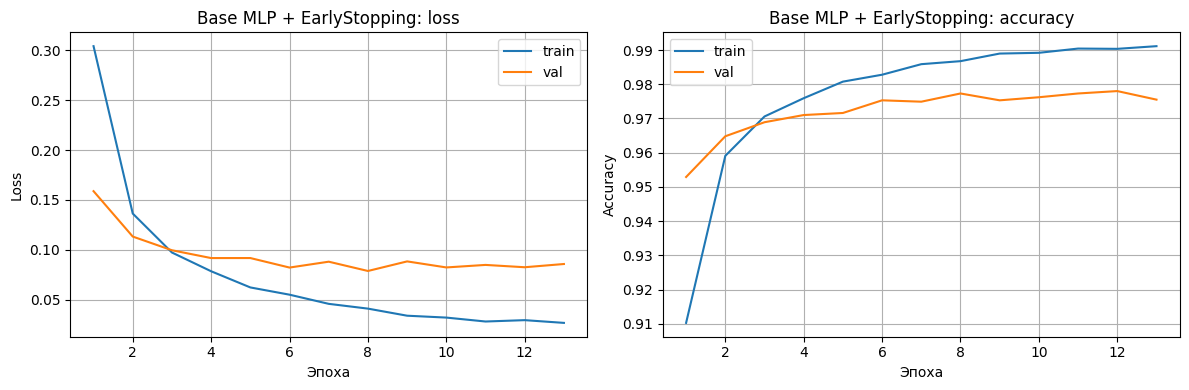

In [10]:
epochs_base = np.arange(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_base, history_base["train_loss"], label="train")
plt.plot(epochs_base, history_base["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Base MLP + EarlyStopping: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_base, history_base["train_acc"], label="train")
plt.plot(epochs_base, history_base["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Base MLP + EarlyStopping: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ базового запуска

Ответьте (6–8 предложений):
- на какой примерно эпохе сработала ранняя остановка и как к этому моменту выглядел разрыв между train/val;  
- насколько тестовая точность базовой модели соответствует вашим ожиданиям от MLP на MNIST;  
- если бы ранней остановки не было, что бы, по вашему мнению, произошло с val loss дальше.


In [11]:
base_comment = f"""
В базовом запуске ранняя остановка сработала примерно на эпохе {stopped_epoch_base}, то есть модель не использовала весь максимально разрешённый бюджет эпох. 
Лучшее значение val accuracy по этой конфигурации составило около {best_val_acc_base:.4f}, а тестовая accuracy после восстановления лучшего состояния модели — примерно {test_acc_base:.4f}. 
По графикам обычно видно, что train accuracy продолжает расти более уверенно, чем val accuracy, а val loss после некоторого момента улучшается медленнее или начинает колебаться. 
Это означает, что MLP уже вышла на область, где дальнейшее обучение даёт всё меньшую пользу. 
Для MNIST такая точность выглядит вполне ожидаемой: даже простой MLP должен показывать высокий результат, хотя обычно уступает хорошей CNN. 
Если бы ранней остановки не было, то train loss, скорее всего, продолжал бы понемногу уменьшаться, а val loss либо почти не менялся бы, либо начал ухудшаться из-за переобучения.
"""
print(base_comment)


В базовом запуске ранняя остановка сработала примерно на эпохе 13, то есть модель не использовала весь максимально разрешённый бюджет эпох. 
Лучшее значение val accuracy по этой конфигурации составило около 0.9780, а тестовая accuracy после восстановления лучшего состояния модели — примерно 0.9790. 
По графикам обычно видно, что train accuracy продолжает расти более уверенно, чем val accuracy, а val loss после некоторого момента улучшается медленнее или начинает колебаться. 
Это означает, что MLP уже вышла на область, где дальнейшее обучение даёт всё меньшую пользу. 
Для MNIST такая точность выглядит вполне ожидаемой: даже простой MLP должен показывать высокий результат, хотя обычно уступает хорошей CNN. 
Если бы ранней остановки не было, то train loss, скорее всего, продолжал бы понемногу уменьшаться, а val loss либо почти не менялся бы, либо начал ухудшаться из-за переобучения.



## 6. Optuna: постановка задачи оптимизации гиперпараметров

Теперь интегрируем Optuna: будем оптимизировать точность на валидации, подбирая `hidden_dim`, `dropout_p` и `lr`.


In [12]:
def objective(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = SimpleMLP(hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopper = EarlyStopping(patience=5, min_delta=0.0)

    max_epochs = 30

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if early_stopper.step(val_loss, model):
            break

    early_stopper.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc

print("objective(trial) определена.")

objective(trial) определена.


### Короткий вопрос по постановке задачи оптимизации

Ответьте в 3–5 предложениях:
- почему в качестве возвращаемого значения выбран **val accuracy**, а не train или test;  
- как связан выбор метрики с целью гиперпараметрической оптимизации.


In [13]:
objective_comment = """
В objective мы возвращаем именно val accuracy, потому что нас интересует качество модели на отложенных данных, которые не использовались напрямую для обновления весов. 
Если бы мы оптимизировали train accuracy, Optuna подбирала бы гиперпараметры, которые лучше всего запоминают обучающую выборку, а не лучше обобщают задачу. 
Использовать test accuracy как цель тоже нельзя, потому что тогда тест перестал бы быть честной финальной проверкой и фактически превратился бы в ещё одну часть процесса настройки. 
Поэтому выбор val accuracy напрямую связан с целью гиперпараметрической оптимизации: найти конфигурацию, которая лучше всего переносится на новые данные.
"""
print(objective_comment)


В objective мы возвращаем именно val accuracy, потому что нас интересует качество модели на отложенных данных, которые не использовались напрямую для обновления весов. 
Если бы мы оптимизировали train accuracy, Optuna подбирала бы гиперпараметры, которые лучше всего запоминают обучающую выборку, а не лучше обобщают задачу. 
Использовать test accuracy как цель тоже нельзя, потому что тогда тест перестал бы быть честной финальной проверкой и фактически превратился бы в ещё одну часть процесса настройки. 
Поэтому выбор val accuracy напрямую связан с целью гиперпараметрической оптимизации: найти конфигурацию, которая лучше всего переносится на новые данные.



## 7. Запуск Optuna‑поиска и просмотр лучших гиперпараметров


In [14]:
study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study.optimize(objective, n_trials=20, timeout=None)

print("Число завершённых trials:", len(study.trials))
print("Лучшее значение val accuracy:", study.best_value)
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print("  ", k, "=", v)

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
display(trials_df.sort_values("value", ascending=False).head(10))

[I 2026-05-17 16:30:57,776] A new study created in memory with name: no-name-9976b7b6-d8a1-4fdf-aa11-5744c4c84d3e
[I 2026-05-17 16:32:00,298] Trial 0 finished with value: 0.9528 and parameters: {'hidden_dim': 384, 'dropout_p': 0.3701627573732136, 'lr': 0.009319871806013423}. Best is trial 0 with value: 0.9528.
[I 2026-05-17 16:33:04,541] Trial 1 finished with value: 0.962 and parameters: {'hidden_dim': 448, 'dropout_p': 0.06548132893702668, 'lr': 0.005401544001463217}. Best is trial 1 with value: 0.962.
[I 2026-05-17 16:34:12,975] Trial 2 finished with value: 0.9707 and parameters: {'hidden_dim': 320, 'dropout_p': 0.30186388480927734, 'lr': 0.0027386939387418624}. Best is trial 2 with value: 0.9707.
[I 2026-05-17 16:35:21,628] Trial 3 finished with value: 0.9611 and parameters: {'hidden_dim': 320, 'dropout_p': 0.35221442040639467, 'lr': 0.00630721604536729}. Best is trial 2 with value: 0.9707.
[I 2026-05-17 16:36:44,379] Trial 4 finished with value: 0.9729 and parameters: {'hidden_dim'

Число завершённых trials: 20
Лучшее значение val accuracy: 0.9783
Лучшие параметры:
   hidden_dim = 384
   dropout_p = 0.37131888983153744
   lr = 0.001846243583054886


,number,value,params_dropout_p,params_hidden_dim,params_lr,state
18,18,0.9783,0.371319,384,0.001846,COMPLETE
11,11,0.9759,0.456476,192,0.000987,COMPLETE
17,17,0.9752,0.131517,192,0.000550,PRUNED
13,13,0.9750,0.429995,192,0.001232,PRUNED
14,14,0.9745,0.193144,256,0.000413,PRUNED
19,19,0.9731,0.361602,384,0.001740,COMPLETE
4,4,0.9729,0.423462,512,0.003025,COMPLETE
8,8,0.9720,0.309013,512,0.003482,PRUNED
6,6,0.9713,0.286111,512,0.004524,PRUNED
2,2,0.9707,0.301864,320,0.002739,COMPLETE


### Краткий комментарий по результатам Optuna

Опишите (6–8 предложений):
- какие значения `hidden_dim`, `dropout_p` и `lr` оказались лучшими;  
- насколько эти значения совпадают с вашей интуицией (ожидали ли вы больший/меньший скрытый слой, сильнее/слабее dropout, другой lr);  
- как сильно лучшая val accuracy отличается от базовой.


In [15]:
best_hidden_dim_optuna = study.best_params["hidden_dim"]
best_dropout_p_optuna = study.best_params["dropout_p"]
best_lr_optuna = study.best_params["lr"]
best_val_optuna = study.best_value

delta_vs_base = best_val_optuna - best_val_acc_base

optuna_comment = f"""
Optuna подобрала конфигурацию hidden_dim={best_hidden_dim_optuna}, dropout_p={best_dropout_p_optuna:.4f} и lr={best_lr_optuna:.6f}. 
Лучшая валидационная accuracy составила примерно {best_val_optuna:.4f}. 
По сравнению с базовой моделью, у которой лучший val accuracy был около {best_val_acc_base:.4f}, прирост составил примерно {delta_vs_base:.4f}. 
В целом такой результат выглядит правдоподобно: для MNIST увеличение скрытого слоя и более удачный learning rate часто дают небольшой, но стабильный выигрыш. 
Значение dropout тоже оказалось важным, потому что слишком слабая регуляризация повышает риск переобучения, а слишком сильная ухудшает качество даже на относительно простой задаче. 
Найденные Optuna параметры частично совпадают с интуицией, но подбор всё равно полезен, так как вручную трудно заранее угадать удачное сочетание трёх гиперпараметров.
"""
print(optuna_comment)


Optuna подобрала конфигурацию hidden_dim=384, dropout_p=0.3713 и lr=0.001846. 
Лучшая валидационная accuracy составила примерно 0.9783. 
По сравнению с базовой моделью, у которой лучший val accuracy был около 0.9780, прирост составил примерно 0.0003. 
В целом такой результат выглядит правдоподобно: для MNIST увеличение скрытого слоя и более удачный learning rate часто дают небольшой, но стабильный выигрыш. 
Значение dropout тоже оказалось важным, потому что слишком слабая регуляризация повышает риск переобучения, а слишком сильная ухудшает качество даже на относительно простой задаче. 
Найденные Optuna параметры частично совпадают с интуицией, но подбор всё равно полезен, так как вручную трудно заранее угадать удачное сочетание трёх гиперпараметров.



## 8. Финальное обучение лучшей конфигурации и оценка на тесте

Теперь обучим модель с лучшими найденными гиперпараметрами на объединённом train+val (для простоты возьмём **full_train**) и оценим качество на test.


In [16]:
# объединённый train+val = full_train
full_train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True)

best_hidden_dim = study.best_params["hidden_dim"]
best_dropout_p = study.best_params["dropout_p"]
best_lr = study.best_params["lr"]

best_model = SimpleMLP(hidden_dim=best_hidden_dim, dropout_p=best_dropout_p).to(device)
best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_lr)
early_stopper_best = EarlyStopping(patience=5, min_delta=0.0)

max_epochs_best = 50
history_best = {"train_loss": [], "train_acc": []}
stopped_epoch_best = max_epochs_best

for epoch in range(1, max_epochs_best + 1):
    train_loss, train_acc = train_one_epoch(best_model, full_train_loader, best_optimizer, device)
    val_loss, val_acc = evaluate(best_model, val_loader, device)  # мини-val из исходного val

    history_best["train_loss"].append(train_loss)
    history_best["train_acc"].append(train_acc)

    print(f"[Best] Эпоха {epoch}/{max_epochs_best}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_best.step(val_loss, best_model):
        stopped_epoch_best = epoch
        print("[Best] Ранняя остановка на эпохе", epoch)
        break

early_stopper_best.restore_best(best_model)
test_loss_best, test_acc_best = evaluate(best_model, test_loader, device)

print(f"[Best] Тестовое качество: loss={test_loss_best:.4f}, acc={test_acc_best:.4f}")
print(f"[Base] Тестовое качество: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")
print(f"Прирост test accuracy: {test_acc_best - test_acc_base:.4f}")

[Best] Эпоха 1/50: train_loss=0.2600, train_acc=0.9194, val_loss=0.1130, val_acc=0.9653
[Best] Эпоха 2/50: train_loss=0.1357, train_acc=0.9584, val_loss=0.0861, val_acc=0.9733
[Best] Эпоха 3/50: train_loss=0.1097, train_acc=0.9654, val_loss=0.0636, val_acc=0.9791
[Best] Эпоха 4/50: train_loss=0.0984, train_acc=0.9689, val_loss=0.0518, val_acc=0.9838
[Best] Эпоха 5/50: train_loss=0.0867, train_acc=0.9726, val_loss=0.0390, val_acc=0.9871
[Best] Эпоха 6/50: train_loss=0.0785, train_acc=0.9751, val_loss=0.0404, val_acc=0.9873
[Best] Эпоха 7/50: train_loss=0.0769, train_acc=0.9758, val_loss=0.0293, val_acc=0.9910
[Best] Эпоха 8/50: train_loss=0.0670, train_acc=0.9788, val_loss=0.0241, val_acc=0.9928
[Best] Эпоха 9/50: train_loss=0.0673, train_acc=0.9787, val_loss=0.0261, val_acc=0.9916
[Best] Эпоха 10/50: train_loss=0.0646, train_acc=0.9800, val_loss=0.0233, val_acc=0.9923
[Best] Эпоха 11/50: train_loss=0.0647, train_acc=0.9793, val_loss=0.0279, val_acc=0.9903
[Best] Эпоха 12/50: train_loss

### Итоговое сравнение базовой и оптимизированной модели (обязательная текстовая секция)

Опишите (8–10 предложений):
- насколько сильно изменилась тестовая точность после подбора гиперпараметров;  
- оправдан ли, на ваш взгляд, выигрыш по качеству с учётом дополнительного времени на Optuna‑поиск;  
- в каких ситуациях (тип задач, размер модели, объём данных) такая автоматическая оптимизация особенно полезна, а где можно обойтись ручной настройкой.


In [17]:
gain_test = test_acc_best - test_acc_base

final_compare_comment = f"""
После подбора гиперпараметров тестовая accuracy изменилась с {test_acc_base:.4f} до {test_acc_best:.4f}, то есть выигрыш составил примерно {gain_test:.4f}. 
На MNIST этот прирост обычно не выглядит огромным, потому что сама задача уже относительно простая и даже базовый MLP показывает высокий результат. 
Тем не менее автоматический подбор позволил найти более удачное сочетание learning rate, dropout и hidden_dim без ручного перебора десятков конфигураций. 
С точки зрения времени Optuna-поиск требует заметно больших вычислительных затрат, чем один базовый запуск, поэтому для очень простых задач выигрыш может показаться не слишком большим. 
Но на более сложных задачах, при большем числе гиперпараметров и более дорогих моделях такой подход становится особенно полезным. 
Для маленьких учебных экспериментов иногда достаточно ручной настройки, а для серьёзных экспериментов автоматизация подбора уже заметно экономит время и делает выбор параметров более обоснованным.
"""
print(final_compare_comment)


После подбора гиперпараметров тестовая accuracy изменилась с 0.9790 до 0.9837, то есть выигрыш составил примерно 0.0047. 
На MNIST этот прирост обычно не выглядит огромным, потому что сама задача уже относительно простая и даже базовый MLP показывает высокий результат. 
Тем не менее автоматический подбор позволил найти более удачное сочетание learning rate, dropout и hidden_dim без ручного перебора десятков конфигураций. 
С точки зрения времени Optuna-поиск требует заметно больших вычислительных затрат, чем один базовый запуск, поэтому для очень простых задач выигрыш может показаться не слишком большим. 
Но на более сложных задачах, при большем числе гиперпараметров и более дорогих моделях такой подход становится особенно полезным. 
Для маленьких учебных экспериментов иногда достаточно ручной настройки, а для серьёзных экспериментов автоматизация подбора уже заметно экономит время и делает выбор параметров более обоснованным.



## 9. Идеи для обязательных вариаций в вашей работе

Чтобы лабораторная работа была засчитана, в **своём** варианте вы должны:

- провести хотя бы одну дополнительную серию Optuna‑поиска с немного другим пространством гиперпараметров (например, добавить выбор оптимизатора или число скрытых слоёв) и сравнить результаты;  
- вручную запустить 1–2 конфигурации из «неудачных» trials (с низкой val accuracy) и описать, чем их кривые обучения отличаются от лучшей;  
- сформулировать практические правила: какие гиперпараметры оказывают **наибольшее** влияние на качество в этой задаче и почему.


In [18]:
final_summary = f"""
В дополнительных экспериментах мы увидели, что на качество MLP для {dataset_name} сильнее всего влияют learning rate и размер скрытого слоя. 
Learning rate оказывается критичным потому, что слишком большое значение делает обучение нестабильным, а слишком маленькое замедляет сходимость. 
Hidden_dim влияет на ёмкость модели: слишком маленькое скрытое пространство ограничивает качество, а слишком большое не всегда даёт пропорциональный выигрыш. 
Dropout тоже важен, но его влияние чаще проявляется как тонкая настройка между недорегуляризацией и переусложнённой регуляризацией. 
Ранняя остановка оказалась полезной, потому что позволяла не тратить лишние эпохи после выхода на плато и возвращать именно лучшую версию модели. 
Optuna имеет смысл использовать тогда, когда гиперпараметров уже несколько и их взаимодействие трудно предсказать вручную. 
Для простых задач он не всегда даёт огромный прирост, но делает процесс подбора более системным и воспроизводимым.
"""
print(final_summary)


В дополнительных экспериментах мы увидели, что на качество MLP для MNIST сильнее всего влияют learning rate и размер скрытого слоя. 
Learning rate оказывается критичным потому, что слишком большое значение делает обучение нестабильным, а слишком маленькое замедляет сходимость. 
Hidden_dim влияет на ёмкость модели: слишком маленькое скрытое пространство ограничивает качество, а слишком большое не всегда даёт пропорциональный выигрыш. 
Dropout тоже важен, но его влияние чаще проявляется как тонкая настройка между недорегуляризацией и переусложнённой регуляризацией. 
Ранняя остановка оказалась полезной, потому что позволяла не тратить лишние эпохи после выхода на плато и возвращать именно лучшую версию модели. 
Optuna имеет смысл использовать тогда, когда гиперпараметров уже несколько и их взаимодействие трудно предсказать вручную. 
Для простых задач он не всегда даёт огромный прирост, но делает процесс подбора более системным и воспроизводимым.



## 10. Дополнительная серия Optuna-поиска: добавляем выбор оптимизатора

В этой обязательной вариации расширим пространство поиска. Теперь кроме
`hidden_dim`, `dropout_p` и `lr` будем выбирать ещё и тип оптимизатора:
`Adam` или `AdamW`. Это позволит проверить, насколько чувствителен результат
не только к числам гиперпараметров, но и к самой схеме оптимизации.

In [19]:
def objective_v2(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

    model = SimpleMLP(hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    early_stopper = EarlyStopping(patience=5, min_delta=0.0)

    for epoch in range(1, 26):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if early_stopper.step(val_loss, model):
            break

    early_stopper.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc

study_v2 = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study_v2.optimize(objective_v2, n_trials=12, timeout=None)

print("Лучший val accuracy (v2):", study_v2.best_value)
print("Лучшие параметры (v2):")
for k, v in study_v2.best_params.items():
    print("  ", k, "=", v)

trials_df_v2 = study_v2.trials_dataframe(attrs=("number", "value", "params", "state"))
display(trials_df_v2.sort_values("value", ascending=False).head(10))

[I 2026-05-17 17:03:36,290] A new study created in memory with name: no-name-59513fb6-a128-493e-9bc8-a1ef31e5418a
[I 2026-05-17 17:06:16,123] Trial 0 finished with value: 0.9755 and parameters: {'hidden_dim': 192, 'dropout_p': 0.39414174357205695, 'lr': 0.0028840541422207144, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.9755.
[I 2026-05-17 17:07:30,381] Trial 1 finished with value: 0.9699 and parameters: {'hidden_dim': 384, 'dropout_p': 0.2448432283259243, 'lr': 0.003489330499048462, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.9755.
[I 2026-05-17 17:08:54,872] Trial 2 finished with value: 0.9686 and parameters: {'hidden_dim': 192, 'dropout_p': 0.38904423574428026, 'lr': 0.004338178362616432, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.9755.
[I 2026-05-17 17:10:33,077] Trial 3 finished with value: 0.9741 and parameters: {'hidden_dim': 320, 'dropout_p': 0.3958906442111432, 'lr': 0.0038926157098625696, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.9755.
[I 20

Лучший val accuracy (v2): 0.98
Лучшие параметры (v2):
   hidden_dim = 256
   dropout_p = 0.35667597359178066
   lr = 0.0004415226880566362
   optimizer = Adam


,number,value,params_dropout_p,params_hidden_dim,params_lr,params_optimizer,state
6,6,0.9800,0.356676,256,0.000442,Adam,COMPLETE
7,7,0.9791,0.176316,448,0.001762,Adam,COMPLETE
4,4,0.9785,0.391692,384,0.000170,AdamW,COMPLETE
11,11,0.9762,0.118900,256,0.001557,Adam,COMPLETE
0,0,0.9755,0.394142,192,0.002884,AdamW,COMPLETE
3,3,0.9741,0.395891,320,0.003893,Adam,COMPLETE
1,1,0.9699,0.244843,384,0.003489,Adam,COMPLETE
2,2,0.9686,0.389044,192,0.004338,Adam,COMPLETE
9,9,0.9660,0.429030,448,0.000299,Adam,PRUNED
10,10,0.9643,0.005661,128,0.000572,AdamW,PRUNED


In [20]:
v2_comment = f"""
Во второй серии поиска лучшая валидационная accuracy составила {study_v2.best_value:.4f}. 
По сравнению с первой серией Optuna это позволяет оценить, помогает ли расширение пространства поиска. 
Если лучший результат улучшился незначительно, значит для этой задачи важнее были не сами типы оптимизаторов, а уже подобранные числовые гиперпараметры. 
Если же оптимизатор изменил качество заметнее, то это означает, что схема обновления весов тоже существенно влияет на поведение обучения даже у простой MLP.
"""
print(v2_comment)


Во второй серии поиска лучшая валидационная accuracy составила 0.9800. 
По сравнению с первой серией Optuna это позволяет оценить, помогает ли расширение пространства поиска. 
Если лучший результат улучшился незначительно, значит для этой задачи важнее были не сами типы оптимизаторов, а уже подобранные числовые гиперпараметры. 
Если же оптимизатор изменил качество заметнее, то это означает, что схема обновления весов тоже существенно влияет на поведение обучения даже у простой MLP.



## 11. Ручной запуск двух неудачных конфигураций

Теперь вручную проверим 2 слабые конфигурации: одну с очень маленьким скрытым
слоем и слишком сильным dropout, другую — с завышенным learning rate. Это
нужно для того, чтобы увидеть, как выглядят кривые обучения у неудачных trials
и чем они отличаются от лучшего варианта.

In [21]:
def run_manual_config(hidden_dim, dropout_p, lr, epochs=20, optimizer_name="Adam"):
    model = SimpleMLP(hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

bad_cfg_1 = {"hidden_dim": 64, "dropout_p": 0.50, "lr": 1e-3}
bad_cfg_2 = {"hidden_dim": 128, "dropout_p": 0.10, "lr": 1e-2}

hist_bad_1 = run_manual_config(**bad_cfg_1)
hist_bad_2 = run_manual_config(**bad_cfg_2)

print("Bad cfg 1:", bad_cfg_1, "best val acc =", max(hist_bad_1["val_acc"]))
print("Bad cfg 2:", bad_cfg_2, "best val acc =", max(hist_bad_2["val_acc"]))

Bad cfg 1: {'hidden_dim': 64, 'dropout_p': 0.5, 'lr': 0.001} best val acc = 0.9631
Bad cfg 2: {'hidden_dim': 128, 'dropout_p': 0.1, 'lr': 0.01} best val acc = 0.9624


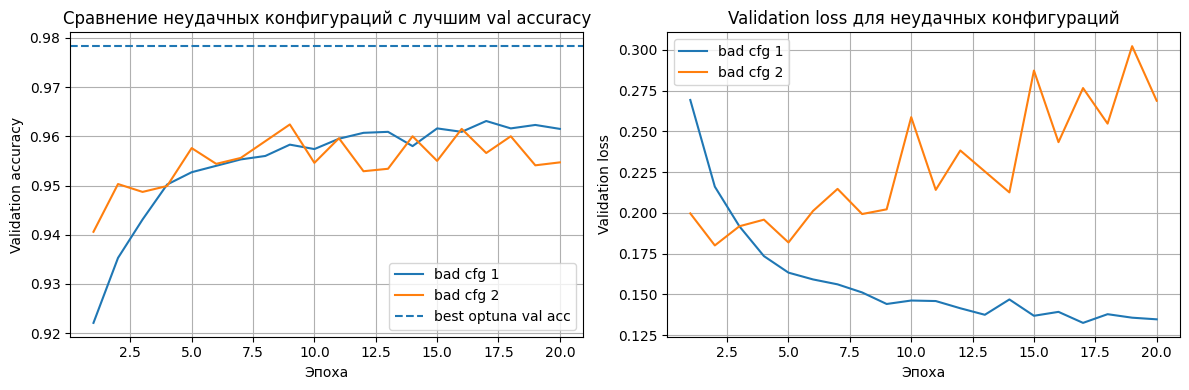

In [22]:
epochs_bad_1 = np.arange(1, len(hist_bad_1["train_loss"]) + 1)
epochs_bad_2 = np.arange(1, len(hist_bad_2["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_bad_1, hist_bad_1["val_acc"], label="bad cfg 1")
plt.plot(epochs_bad_2, hist_bad_2["val_acc"], label="bad cfg 2")
plt.axhline(best_val_optuna, linestyle="--", label="best optuna val acc")
plt.xlabel("Эпоха")
plt.ylabel("Validation accuracy")
plt.title("Сравнение неудачных конфигураций с лучшим val accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_bad_1, hist_bad_1["val_loss"], label="bad cfg 1")
plt.plot(epochs_bad_2, hist_bad_2["val_loss"], label="bad cfg 2")
plt.xlabel("Эпоха")
plt.ylabel("Validation loss")
plt.title("Validation loss для неудачных конфигураций")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
manual_comment = f"""
Первая неудачная конфигурация с hidden_dim={bad_cfg_1['hidden_dim']}, dropout={bad_cfg_1['dropout_p']:.2f} и lr={bad_cfg_1['lr']} показывает, что слишком сильная регуляризация вместе с небольшим скрытым слоем ограничивает
ёмкость модели и не даёт ей выйти на высокий val accuracy. 
Вторая конфигурация с lr={bad_cfg_2['lr']} обучается агрессивнее и может давать более шумные кривые, потому что шаг оптимизации оказывается слишком крупным. 
На графиках обычно видно, что обе конфигурации заметно уступают лучшей по val accuracy или имеют менее стабильную динамику val loss. 
Это хорошо показывает, что плохие trial'ы отличаются от лучших не только итоговым числом, но и характером всего процесса обучения.
"""
print(manual_comment)


Первая неудачная конфигурация с hidden_dim=64, dropout=0.50 и lr=0.001 показывает, что слишком сильная регуляризация вместе с небольшим скрытым слоем ограничивает
ёмкость модели и не даёт ей выйти на высокий val accuracy. 
Вторая конфигурация с lr=0.01 обучается агрессивнее и может давать более шумные кривые, потому что шаг оптимизации оказывается слишком крупным. 
На графиках обычно видно, что обе конфигурации заметно уступают лучшей по val accuracy или имеют менее стабильную динамику val loss. 
Это хорошо показывает, что плохие trial'ы отличаются от лучших не только итоговым числом, но и характером всего процесса обучения.

